In [1]:
import os

os.getcwd()

'C:\\Users\\Vaishnavi\\Downloads\\open+university+learning+analytics+dataset'

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("studentinfo.csv")

In [4]:
df.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   code_module           32593 non-null  object
 1   code_presentation     32593 non-null  object
 2   id_student            32593 non-null  int64 
 3   gender                32593 non-null  object
 4   region                32593 non-null  object
 5   highest_education     32593 non-null  object
 6   imd_band              32593 non-null  object
 7   age_band              32593 non-null  object
 8   num_of_prev_attempts  32593 non-null  int64 
 9   studied_credits       32593 non-null  int64 
 10  disability            32593 non-null  object
 11  final_result          32593 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.0+ MB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df["final_result"].value_counts()

final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

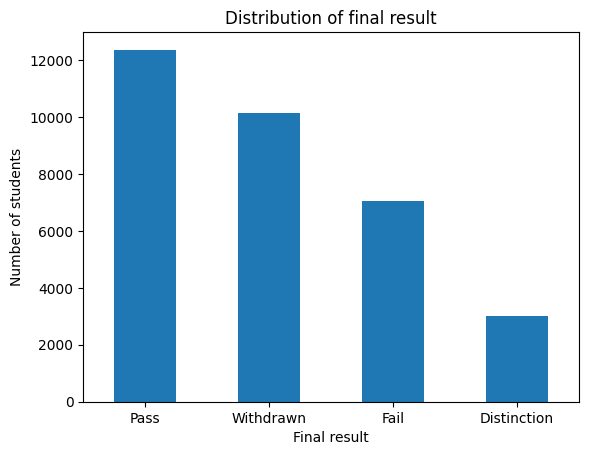

In [8]:
import matplotlib.pyplot as plt

df["final_result"].value_counts().plot(kind="bar")

plt.title("Distribution of final result")
plt.xlabel("Final result")
plt.ylabel("Number of students")
plt.xticks(rotation = 0)
plt.show()

In [9]:
df["highest_education"].value_counts()

highest_education
A Level or Equivalent          14045
Lower Than A Level             13158
HE Qualification                4730
No Formal quals                  347
Post Graduate Qualification      313
Name: count, dtype: int64

In [10]:
df["age_band"].value_counts()

age_band
0-35     22944
35-55     9433
55<=       216
Name: count, dtype: int64

In [11]:
df.describe()

,id_student,num_of_prev_attempts,studied_credits
count,3.259300e+04,32593.000000,32593.000000
mean,7.066877e+05,0.163225,79.758691
std,5.491673e+05,0.479758,41.071900
min,3.733000e+03,0.000000,30.000000
25%,5.085730e+05,0.000000,60.000000
50%,5.903100e+05,0.000000,60.000000
75%,6.444530e+05,0.000000,120.000000
max,2.716795e+06,6.000000,655.000000


In [12]:
df["num_of_prev_attempts"].value_counts().sort_index()

num_of_prev_attempts
0    28421
1     3299
2      675
3      142
4       39
5       13
6        4
Name: count, dtype: int64

In [13]:
df["studied_credits"].value_counts().sort_index()

studied_credits
30     3749
40       22
45       36
50        7
55        3
       ... 
480       1
540       1
585       1
630       1
655       1
Name: count, Length: 61, dtype: int64

In [14]:
df["studied_credits"].value_counts().head(10)

studied_credits
60     16751
120     6328
30      3749
90      3144
180      830
150      769
240      220
210      169
75       108
70        96
Name: count, dtype: int64

In [15]:
df["disability"].value_counts()

disability
N    29429
Y     3164
Name: count, dtype: int64

In [16]:
df["final_result"].value_counts()

final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

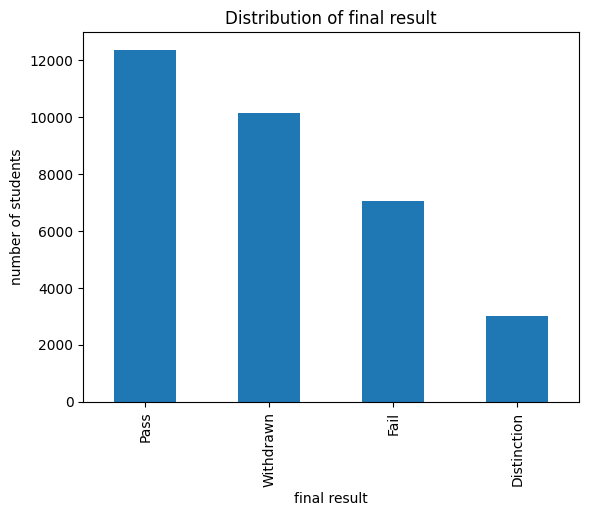

In [17]:
df["final_result"].value_counts().plot(kind="bar")
plt.title("Distribution of final result")
plt.xlabel("final result")
plt.ylabel("number of students")
plt.show()

In [18]:
df["final_result"].value_counts(normalize=True) * 100

final_result
Pass           37.925321
Withdrawn      31.160065
Fail           21.636548
Distinction     9.278066
Name: proportion, dtype: float64

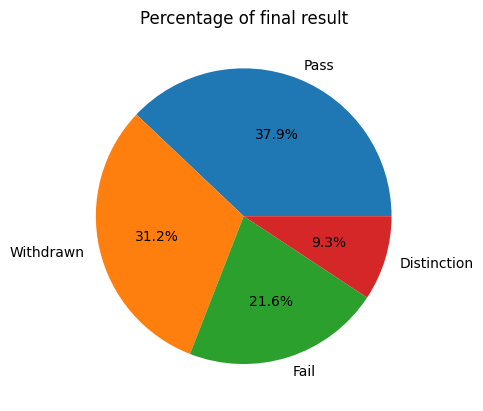

In [19]:
df["final_result"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("Percentage of final result")
plt.ylabel("")
plt.show()

In [20]:
X = df.drop(columns=["final_result", "id_student"])

y = df["final_result"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (32593, 10)
Target shape: (32593,)


In [21]:
X.dtypes

code_module             object
code_presentation       object
gender                  object
region                  object
highest_education       object
imd_band                object
age_band                object
num_of_prev_attempts     int64
studied_credits          int64
disability              object
dtype: object

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [23]:
X = df.drop(columns=["final_result","id_student"])
Y = df["final_result"]

print("X created:", X.shape)
print("Y created:", Y.shape)

X created: (32593, 10)
Y created: (32593,)


In [24]:
categorical_columns = X.select_dtypes(include = ["object"]).columns
print(categorical_columns)

Index(['code_module', 'code_presentation', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'disability'],
      dtype='object')


In [25]:
numerical_columns = X.select_dtypes(include = ["int64","float64"]).columns
print(numerical_columns)

Index(['num_of_prev_attempts', 'studied_credits'], dtype='object')


In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
        ("numerical", "passthrough", numerical_columns)
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [27]:
X_processed = preprocessor.fit_transform(X)

print("Original shape:", X.shape)
print("Processed shape:",X_processed.shape)

Original shape: (32593, 10)
Processed shape: (32593, 49)


In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    X_processed,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify=y

)
print("Training features:",X_train.shape)
print("Testing features:",X_test.shape)
print("Training target",Y_train.shape)
print("Testing target",Y_test.shape)

Training features: (26074, 49)
Testing features: (6519, 49)
Training target (26074,)
Testing target (6519,)


In [29]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
print("model created successfully")

model created successfully


In [30]:
model.fit(X_train, Y_train)
print("Model trained successfully")

Model trained successfully


C:\Users\Vaishnavi\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [31]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=3000)

print("Model updated successfully!")

Model updated successfully!


In [32]:
model.fit(X_train, Y_train)

print("Model trained successfully!")

Model trained successfully!


In [33]:
print("Model training completed!")
print("Iterations used:", model.n_iter_)

Model training completed!
Iterations used: [1043]


In [34]:
Y_pred = model.predict(X_test)
print("Model training completed!")
print("Iterations used:", model.n_iter_)

Model training completed!
Iterations used: [1043]


In [35]:
Y_pred = model.predict(X_test)
print("Predictions created successfully!")
print("Number of predictions:", len(Y_pred))

Predictions created successfully!
Number of predictions: 6519


In [36]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(Y_test, Y_pred)
print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy*100,"%")

Model Accuracy: 0.4462340849823593
Accuracy Percentage: 44.623408498235925 %


In [37]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,Y_pred))

              precision    recall  f1-score   support

 Distinction       0.62      0.01      0.03       605
        Fail       0.39      0.11      0.17      1411
        Pass       0.45      0.70      0.55      2472
   Withdrawn       0.45      0.50      0.47      2031

    accuracy                           0.45      6519
   macro avg       0.48      0.33      0.30      6519
weighted avg       0.45      0.45      0.39      6519



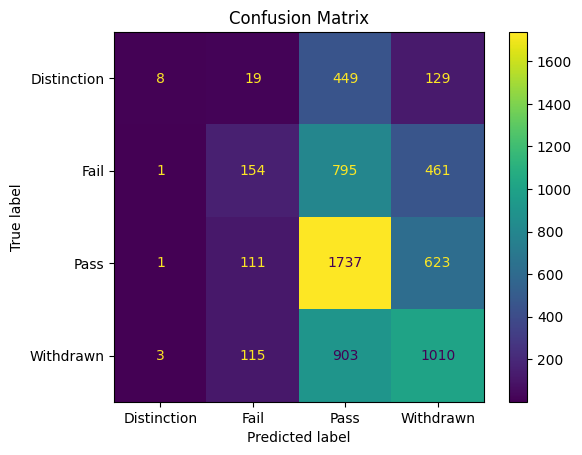

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_predictions(Y_test, Y_pred)
plt.title("Confusion Matrix")
plt.show()

In [40]:
from sklearn.linear_model import LogisticRegression
balanced_model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced"
    
)
balanced_model.fit(X_train, Y_train)
balanced_pred = balanced_model.predict(X_test)
print("Balanced model trained successfully")

Balanced model trained successfully


In [41]:
from sklearn.metrics import accuracy_score, classification_report
balanced_accuracy = accuracy_score(Y_test, balanced_pred)

print("Balanced Model Accuracy:", balanced_accuracy)
print("Accuracy Percentage:", balanced_accuracy * 100 , "%")
print("\nClassification Report:")
print(classification_report(Y_test, balanced_pred))

Balanced Model Accuracy: 0.3522012578616352
Accuracy Percentage: 35.22012578616352 %

Classification Report:
              precision    recall  f1-score   support

 Distinction       0.18      0.57      0.28       605
        Fail       0.32      0.37      0.34      1411
        Pass       0.49      0.21      0.30      2472
   Withdrawn       0.47      0.45      0.46      2031

    accuracy                           0.35      6519
   macro avg       0.37      0.40      0.34      6519
weighted avg       0.42      0.35      0.35      6519



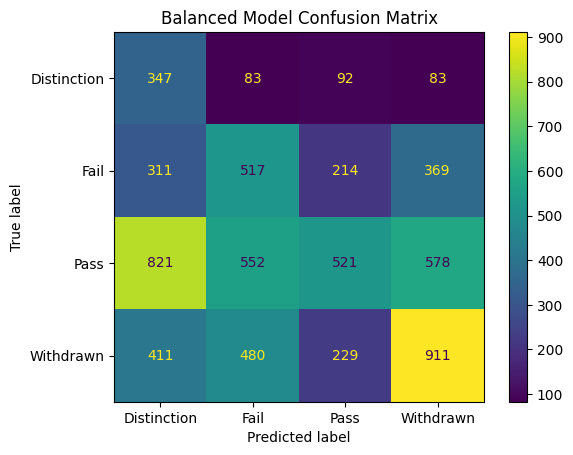

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_predictions(Y_test,balanced_pred)
plt.title("Balanced Model Confusion Matrix")
plt.show()

In [43]:
comparison = pd.DataFrame({
"Actual Result":Y_test.values,
    "original Prediction": Y_pred,
    "Balanced Prediction":balanced_pred
})
comparison.head(20)

,Actual Result,original Prediction,Balanced Prediction
0,Fail,Pass,Distinction
1,Pass,Pass,Distinction
2,Fail,Withdrawn,Withdrawn
3,Withdrawn,Withdrawn,Withdrawn
4,Fail,Pass,Withdrawn
5,Pass,Pass,Pass
6,Distinction,Pass,Distinction
7,Fail,Withdrawn,Fail
8,Pass,Pass,Fail
9,Fail,Pass,Fail


In [45]:
from sklearn.tree import DecisionTreeClassifier as DST
dst = DST(
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)
dst.fit(X_train,Y_train)
print("Decision TREE trained Successfully!")

Decision TREE trained Successfully!


In [46]:
tree_pred = dst.predict(X_test)
print("Decision Tree predictions created!")
print("Number of predictions:",len(tree_pred))

Decision Tree predictions created!
Number of predictions: 6519


In [48]:
from sklearn.metrics import accuracy_score, classification_report

tree_accuracy = accuracy_score(Y_test, tree_pred)

print("Decision Tree Accuracy:", tree_accuracy)
print("Accuracy Percentage:", tree_accuracy * 100, "%")

print("\nClassification Report:")
print(classification_report(Y_test, tree_pred))

Decision Tree Accuracy: 0.3362478907807946
Accuracy Percentage: 33.62478907807946 %

Classification Report:
              precision    recall  f1-score   support

 Distinction       0.17      0.48      0.25       605
        Fail       0.28      0.39      0.33      1411
        Pass       0.45      0.32      0.38      2472
   Withdrawn       0.48      0.28      0.35      2031

    accuracy                           0.34      6519
   macro avg       0.35      0.37      0.33      6519
weighted avg       0.40      0.34      0.35      6519



<function matplotlib.pyplot.show(close=None, block=None)>

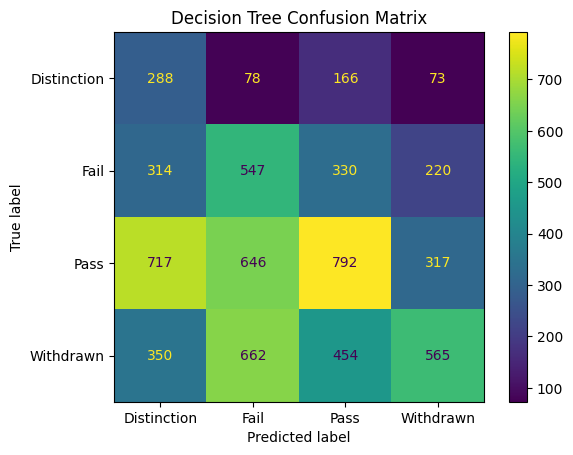

In [49]:
ConfusionMatrixDisplay.from_predictions(Y_test, tree_pred)
plt.title("Decision Tree Confusion Matrix")
plt.show

In [51]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)
rf.fit(X_train, Y_train)
print("Random Forest trained successfully")

Random Forest trained successfully


In [52]:
rf_pred = rf.predict(X_test)
print("Random Forest predictions created!")
print("Number of predictions:",len(rf_pred))

Random Forest predictions created!
Number of predictions: 6519


In [54]:
from sklearn.metrics import accuracy_score, classification_report

rf_accuracy = accuracy_score(Y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)
print("Accuracy Percentage:", rf_accuracy * 100, "%")

print("\nClassification Report:")
print(classification_report(Y_test, rf_pred))

Random Forest Accuracy: 0.3541954287467403
Accuracy Percentage: 35.41954287467403 %

Classification Report:
              precision    recall  f1-score   support

 Distinction       0.18      0.54      0.27       605
        Fail       0.31      0.34      0.33      1411
        Pass       0.48      0.25      0.33      2472
   Withdrawn       0.47      0.44      0.45      2031

    accuracy                           0.35      6519
   macro avg       0.36      0.39      0.34      6519
weighted avg       0.41      0.35      0.36      6519



(0.0, 1.0)

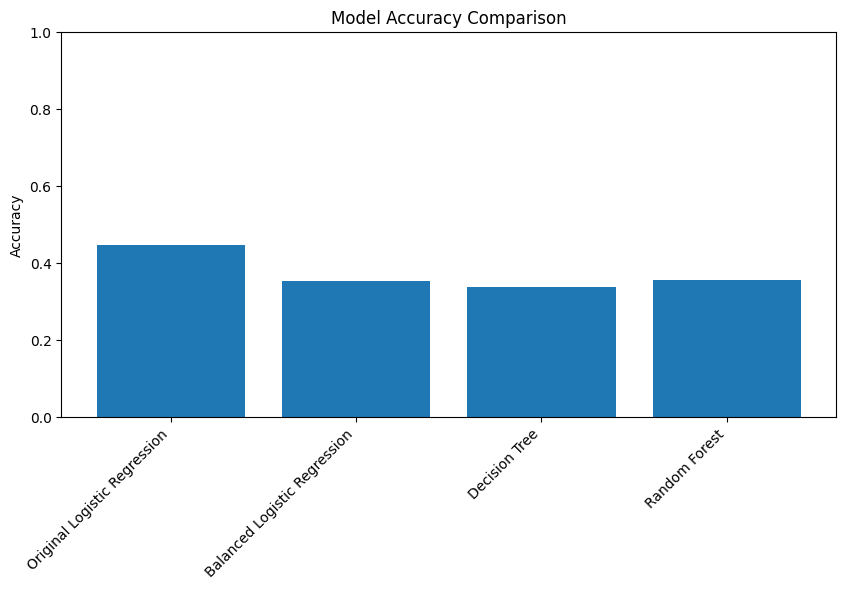

In [57]:
models = [
    "Original Logistic Regression",
    "Balanced Logistic Regression",
    "Decision Tree",
    "Random Forest"
]

accuracies = [
    accuracy,
    balanced_accuracy,
    tree_accuracy,
    rf_accuracy
]
plt.figure(figsize=(10,5))
plt.bar(models,accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")
plt.ylim(0,1)

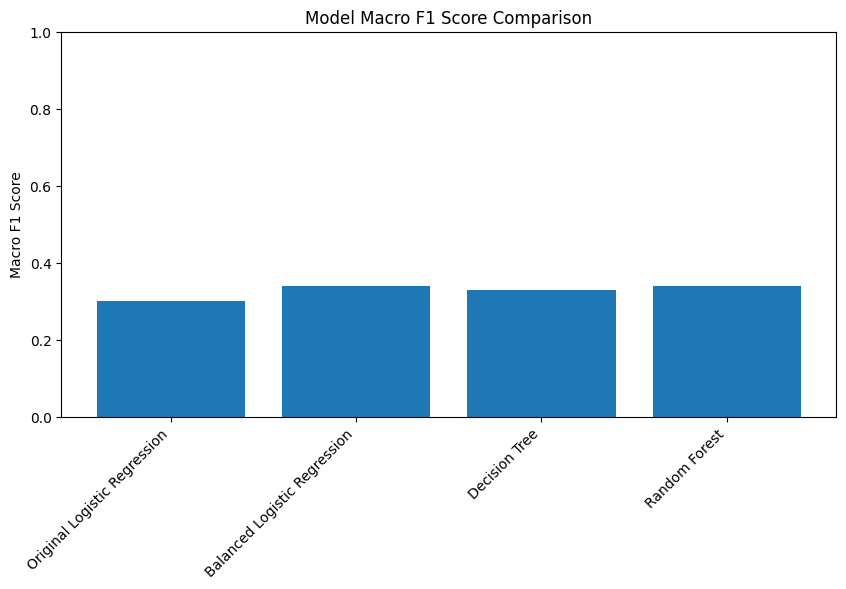

In [58]:
macro_f1_scores = [
    0.30,  
    0.34,  
    0.33, 
    0.34   
]

plt.figure(figsize=(10, 5))
plt.bar(models, macro_f1_scores)

plt.title("Model Macro F1 Score Comparison")
plt.ylabel("Macro F1 Score")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)

plt.show()

In [59]:
comparison = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracies,
    "Macro F1": macro_f1_scores
})

comparison

,Model,Accuracy,Macro F1
0,Original Logistic Regression,0.446234,0.30
1,Balanced Logistic Regression,0.352201,0.34
2,Decision Tree,0.336248,0.33
3,Random Forest,0.354195,0.34


In [60]:
feature_names = preprocessor.get_feature_names_out()

importances = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
48,numerical__studied_credits,0.125690
28,categorical__highest_education_Lower Than A Level,0.084479
47,numerical__num_of_prev_attempts,0.060182
6,categorical__code_module_GGG,0.035880
2,categorical__code_module_CCC,0.035784
27,categorical__highest_education_HE Qualification,0.031817
26,categorical__highest_education_A Level or Equi...,0.029606
10,categorical__code_presentation_2014J,0.027384
42,categorical__age_band_0-35,0.026683
3,categorical__code_module_DDD,0.024369


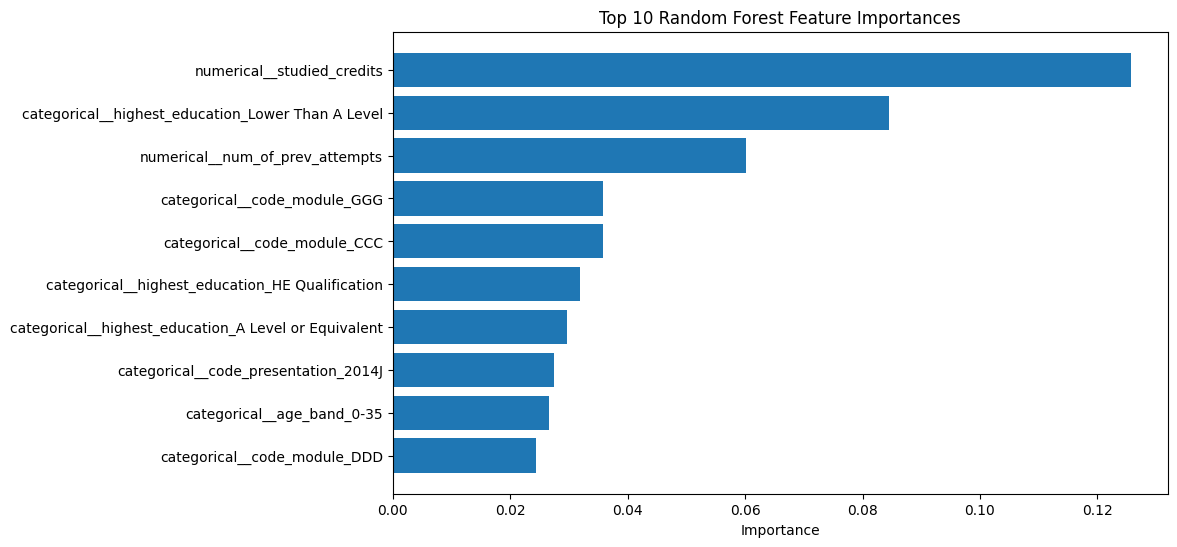

In [61]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()